In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
from scipy import integrate

from datetime import datetime
import pickle # for saving simulations
from pybamm import exp, constants
from scipy.optimize import least_squares
from scipy.optimize import minimize
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline, lagrange, CubicSpline, PPoly,splrep, splev, PchipInterpolator, pchip_interpolate, pchip
from numpy.polynomial.polynomial import Polynomial

import gzip
import time
import optuna
import openpyxl
#import galvani
from galvani import res2sqlite
import sqlite3
import cellpy
import Siegel2022

OKCYAN = '\033[96m'
ENDC = '\033[0m'
# optuna.logging.set_verbosity(optuna.logging.INFO) #WARNING
# %matplotlib ipympl

## Setup simulation

### Load Biologic and vdf data

In [2]:
# load and format vdf data
vdf_data0=pd.read_csv('Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1_AuxDat_TC40_20230228_164816.csv', sep='\t',skiprows=[0,1,2,3,5],header=0)
vdf_data0 = vdf_data0.rename(columns={
    "Test Time": "t", 
    'Current': 'I',
    'Potential':'V',
    'Timestamp': 'timestamp',
    'Vpos': 'V_pos',
    'Vneg': 'V_neg',
    })
vdf_data0['timestamp'] = vdf_data0['timestamp']/1000 # epoch time time in ms and convert to s


# load and format cycler data
biologic_file = ["Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1.res", 
            "Z:/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RATE_1_P25C_P5P0PSI_20230302_R1.res"]
c = cellpy.get(biologic_file, mass=1)
cycler_data0 = c.data.raw
cycler_data0['timestamp'] = cycler_data0.date_time.astype(np.int64)/10**9+3600*4-1855-90# UTC offset for EST, need to also be cognizent of DST?
cycler_data0 = cycler_data0.rename(columns={
    "test_time": "t", 
    "current": "I",
    "voltage": "V",
    "charge_capacity":"Q_c",
    "discharge_capacity": "Q_d",
    })
cycler_data0["I"]=-c.data.raw.current

Could not set custom log-dir - non-existing directory
Dir: c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\degradation_model\tuning_umbl2022feb\cellpy_data\logs
Using current directory instead: c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\degradation_model\tuning_umbl2022feb


In [3]:
# Select hppc cycler data
start = cycler_data0[cycler_data0.I==0].first_valid_index() # start of rest before hppc
end = cycler_data0[abs(cycler_data0.I - (-1.75)) <0.01].first_valid_index()-1 # end of hppc = start of charge
cycler_data = cycler_data0[start:end].copy()
cycler_data.reset_index(drop=True, inplace=True)

# Select corresponding vdf_data
start_vdf = np.argmin(abs(vdf_data0.timestamp - cycler_data0.timestamp[start]))
end_vdf = np.argmin(abs(vdf_data0.timestamp -  cycler_data0.timestamp[end])) 
vdf_data = vdf_data0.iloc[start_vdf:end_vdf].copy()
vdf_data.reset_index(drop=True, inplace=True)
# vdf_data.set_index('timestamp', inplace=True)

# reset test time 
vdf_data.t = vdf_data.t - vdf_data.t.iloc[0] + (cycler_data.timestamp.iloc[0]-vdf_data.timestamp.iloc[0])
cycler_data.t = cycler_data.t-cycler_data.t.iloc[0]

# check that cycler and vdf data are aligned
print(f"Start timestamps error: {cycler_data.timestamp.iloc[0]-vdf_data.timestamp.iloc[0]}", "s")
print(f"End timestamps error: {cycler_data.timestamp.iloc[-1]-vdf_data.timestamp.iloc[-1]}", "s")


Start timestamps error: 0.35899996757507324 s
End timestamps error: 3.1589999198913574 s


In [4]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    return index

downsample_idx = downsample_data(cycler_data.t,cycler_data.I,cycler_data.V,5e-3,.5,230)

cycler_data_ds = cycler_data[downsample_idx]
cycler_data_ds.reset_index(drop=True, inplace=True)

# fig,ax = plt.subplots(2,1, sharex=True)
# ax1 = ax.flat[0]
# ax1.plot(t_data0,V_data0)
# ax1.plot(t_data,V_data,'x')
# ax1.set_ylabel('Voltage [V]')
# ax2 = ax.flat[1]
# ax2.plot(t_data0,I_data0)
# ax2.plot(t_data,I_data,'x')
# ax2.set_ylabel('Current [A]')
# plt.show()

C:\Users\Vivian\AppData\Local\Temp\ipykernel_2572\4108622461.py:5: RuntimeWarning: divide by zero encountered in divide
  deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_2572\4108622461.py:6: RuntimeWarning: invalid value encountered in divide
  di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)


### Identify pulses and separate pulse data

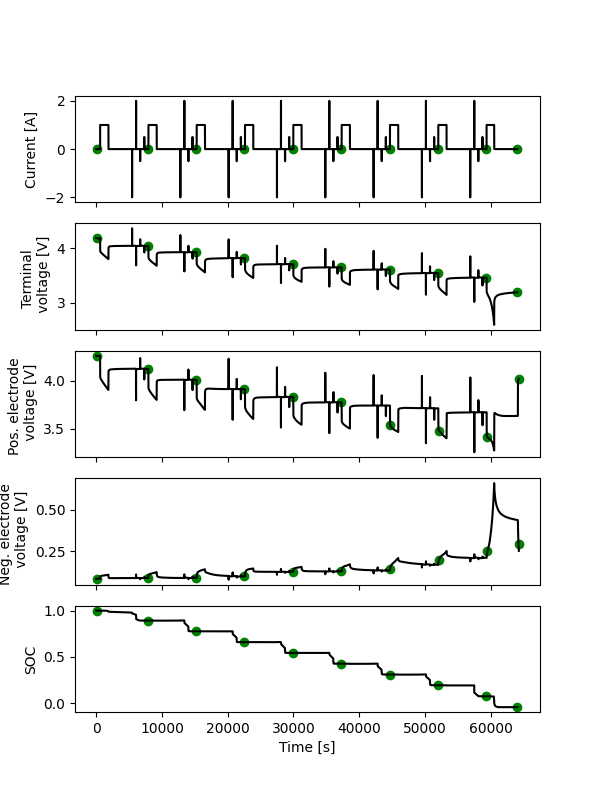

In [5]:
%matplotlib widget 
V_offset = 3.34+0.084

t_data, I_data, V_data = cycler_data_ds.t, cycler_data_ds.I, cycler_data_ds.V
t_data_vdf, V_neg_data, V_pos_data = vdf_data.t, vdf_data.V_neg, vdf_data.V_pos

soc_data = 1 + (integrate.cumulative_trapezoid(I_data[::-1],t_data[::-1]/3600,initial=0))/3.004 

# find pulse indices crom cycler data
pulse_current = 1
pulse_idx = np.where((np.diff(I_data)>0.1)& (abs(I_data[1:]-pulse_current)< 0.1))[0] -10 # indices with large change in current to value close to pulse_current
pulse_idx = np.append(pulse_idx,len(I_data)-1) #add end of hppc

# find matching test times in vdf
desired_timestamps = cycler_data_ds.timestamp.loc[pulse_idx]
mapped_indices_uniq = pd.Index(vdf_data.timestamp).get_indexer(list(desired_timestamps), method='nearest', tolerance = 5)
matched_des_time_indices = np.argwhere(mapped_indices_uniq!=-1)[:,0] #indices of mapped_indices_uniq that are not -1 = desired_timestamps with valid matches
matched_timestamps = vdf_data.timestamp.iloc[mapped_indices_uniq].index
pulse_idx_vdf = vdf_data.timestamp.index.get_indexer_for(matched_timestamps)

# plot
fig, axs = plt.subplots(5,1, figsize=(6,8), sharex=True)
axs = axs.flatten()
data_color = 'k'
ax = axs[0]
ax.plot(t_data,I_data, label='Data', color = data_color)
ax.scatter(t_data[pulse_idx], I_data[pulse_idx], color = 'green')
ax.set_ylabel('Current [A]')

ax = axs[1]
ax.plot(t_data, V_data,color = data_color)
ax.scatter(t_data[pulse_idx], V_data[pulse_idx], color = 'green')
ax.set_ylabel('Terminal \n voltage [V]')

ax = axs[2]
ax.plot(t_data_vdf, V_offset + V_pos_data,color = data_color)
ax.scatter(t_data_vdf[pulse_idx_vdf], V_offset + V_pos_data[pulse_idx_vdf], color = 'green')
ax.set_ylabel('Pos. electrode \n voltage [V]')

ax = axs[3]
ax.plot(t_data_vdf, V_offset - V_neg_data,color = data_color)
ax.scatter(t_data_vdf[pulse_idx_vdf], V_offset - V_neg_data[pulse_idx_vdf], color = 'green')
ax.set_ylabel('Neg. electrode \n voltage [V]')

ax = axs[4]
ax.plot(t_data, soc_data, color = data_color)
ax.scatter(t_data[pulse_idx], soc_data[pulse_idx], color = 'green')
ax.set_xlabel('Time [s]')
ax.set_ylabel('SOC')

plt.show()


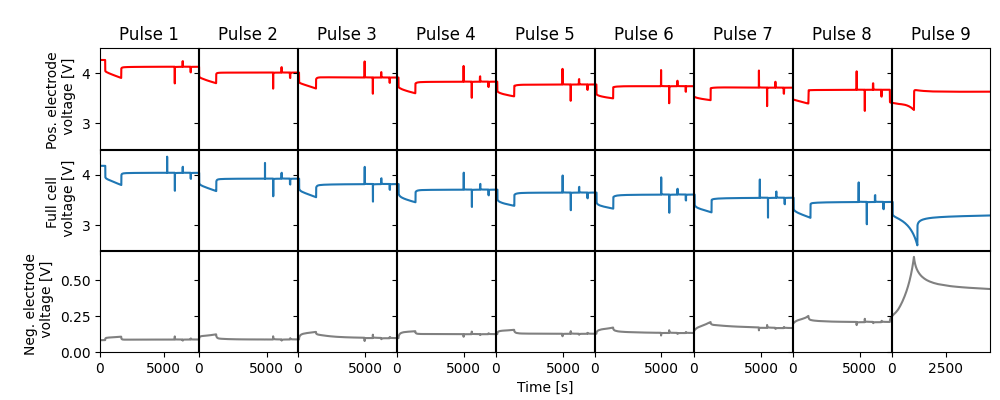

In [6]:
pulses = [] # list of dfs

# build dicts
for ((start, end),(start_vdf, end_vdf)) in zip(zip(pulse_idx[0:-1],pulse_idx[1::]), zip(pulse_idx_vdf[0:-1],pulse_idx_vdf[1::])):
        pulse = {"t": t_data[start:end].values - t_data[start],
                "t0": t_data[start],
                "I": I_data[start:end].values,
                "V": V_data[start:end].values,
                "SOC":soc_data[start:end],
                "t_vdf": t_data_vdf[start_vdf:end_vdf].values - t_data_vdf[start_vdf], 
                "t_vdf0":t_data_vdf[start_vdf],
                "V_neg_data": V_neg_data[start_vdf:end_vdf].values,
                "V_pos_data":V_pos_data[start_vdf:end_vdf].values,
                }
        pulses.append(pulse)

# list of dicts to df
pulses = pd.DataFrame(pulses)

fig,axs = plt.subplots(3,9, figsize = (10,4))
# fig,ax = plt.subplots(4,1,figsize=(8,8), sharex=True)
plt.subplots_adjust(hspace=0.01, wspace=0.01, left=0.1, right=0.99, bottom=0.12)
# axs = axs.flatten()
V_offset = 3.34+0.084
for i,pulse in pulses.iterrows():
        
        # V_data_full = V_data
        # V_data_neg = V_offset - V_neg_data
        # V_data_pos = V_offset + V_pos_data
        ax = axs[0,i]
        ax.plot(pulse.t_vdf, V_offset + pulse.V_pos_data, color = 'red')
        ax.set_title(f'Pulse {i+1}')
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Pos. electrode \n voltage [V]")
        ax.set_xticklabels([])
        ax.set_ylim([2.5,4.5])
        ax.set_xlim([pulse.t[0], pulse.t[-1]])
        
        ax = axs[1,i]
        ax.plot(pulse.t, pulse.V, )
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Full cell \n voltage [V]")
        ax.set_xticklabels([])
        ax.set_ylim([2.5,4.5])
        ax.set_xlim([pulse.t[0], pulse.t[-1]])

        ax = axs[2,i]
        ax.plot(pulse.t_vdf, V_offset - pulse.V_neg_data, color = 'grey')
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Neg. electrode \n voltage [V]")
        ax.set_ylim([0,0.7])
        ax.set_xlim([pulse.t[0], pulse.t[-1]])

axs[2,4].set_xlabel("Time [s]")
plt.savefig('./figs/3E_hppc_data.jpg',format='jpg',dpi=300)


### Set up static parameters

In [7]:
# cathode diffusion
def NMC_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("posDiffusion")
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# anode diffusion
def graphite_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("negDiffusion")
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# cathode kinetics
def NMC_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("posKinetics")
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (
        m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# anode kinetics
def graphite_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("negKinetics")
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)

def electrolyte_diffusivity_Dix(c_e, T):
    """
    Diffusivity of LiPF6 in EC:EMC vol 3:7 with 2 wt% VC as a function of
    ion concentration.
    The original data is from [1]. The Fitting Funciton is from [2]

    References
    ----------
    .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve Porous
    Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells." 2023
    J. Electrochem. Soc. 170 083503
    DOI 10.1149/1945-7111/aceca8
       [2] Lars Ole Valøen and Jan N. Reimers. "Transport Properties of LiPF6-Based
       Li-Ion Battery Electrolytes." 2005 J. Electrochem. Soc. 152 A882 Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte diffusivity
    """

    # Diffusivity in 10E-10 m^2/s = 0.0001*10^((D00+ D01 / (T -
    # ((Tg0 + Conc * Tg1))))+ (D10+ D11/ (T - ((Tg0 + Conc* Tg1)))) * Conc)
    # Where Conc is in units of M and T is in K

    D00 = -487.2
    D01 = -28530000
    Tg0 = 58320
    Tg1 = 50.31
    D10 = -52.79
    D11 = -3061000
    c_e_M = c_e / 1000
    D_c_e = (
        (10**-10)
        * 0.0001
        * 10
        ** (
            (D00 + D01 / (T - ((Tg0 + c_e_M * Tg1))))
            + (D10 + D11 / (T - ((Tg0 + c_e_M * Tg1)))) * c_e_M
        )
    )

    return D_c_e #*pybamm.InputParameter("electDiff")


def electrolyte_conductivity_Dix(c_e, T):
    """
    Conductivity of LiPF6 in 3:7 EC:DMC as a function of ion concentration. The original
    data is from [1].

    References
    ----------
    ..     .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve
    Porous Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells."
    2023 J. Electrochem. Soc. 170 083503 DOI 10.1149/1945-7111/aceca8.

    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte conductivity
    """
    k_Kmax = 3.58e-7
    k_Cmax = 4.84e-6
    k_a = 0.4793
    k_P2 = -0.3299
    k_P1 = 2.22e-14
    k_Ea = 13490
    k_Rg = 8.314
    k_T0 = 162.5
    # Conductivity in mS/cm = 1000*(k_Kmax* (Conc / K_Cmax) ^ k_a *
    # EXP(k_P2 * (Conc – k_Cmax) ^ 2 – k_P1 * (Conc- K_Cmax) / K_Cmax)
    # * EXP(-k_Ea / k_Rg * (1 / T - 1 / K_T0)))
    # Where Conc is in units of M and T is in K
    # convert to S/m
    c_e_M = c_e / 1000

    sigma_e = 100 * (
        k_Kmax
        * (c_e_M / k_Cmax) ** k_a
        * pybamm.exp(k_P2 * (c_e_M - k_Cmax) ** 2 - k_P1 * (c_e_M - k_Cmax) / k_Cmax)
        * pybamm.exp(-k_Ea / k_Rg * (1 / T - 1 / k_T0))
    )

    return sigma_e#*pybamm.InputParameter("electCond")

In [8]:
spme = pybamm.lithium_ion.SPMe()
#spme = pybamm.lithium_ion.DFN()

param_dict = Siegel2022.get_parameter_values()
parameter_values = pybamm.ParameterValues(param_dict)  
param0 = 0.5*6.748678940622972e-14
param1 = 4*1.0122133310725916e-14
param2 = 0.25*1.3715539078341868e-07
param3 = 1.2178795378580133e-06


param = spme.param
# Cap=3.5
# x_100=0.867
# y_100=0.3083
# initial_soc=0.9

C_n_init = 4.0458 
C_p_init = 5.4828

#Cell 901 update
Cap=3.004
x_100=0.74
y_100=0.3083
C_n_init = 4.5 
C_p_init = 4.6

x_0=x_100-Cap/C_n_init
y_0=y_100+Cap/C_p_init
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))


# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Lower voltage cut-off [V]": 2.4, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

parameter_values.update(
    {
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
        "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
        "Electrolyte diffusivity [m2.s-1]": electrolyte_diffusivity_Dix,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity_Dix,
        "Cation transference number": 0.25,
        "Separator porosity": 0.2,
        "Positive electrode porosity": 0.2,
        "Negative electrode porosity": 0.15,
        "Separator thickness [m]": 2*1.2e-05,
        })                 

L_n = spme.param.n.L  # Negative electrode thickness [m]
L_s = spme.param.s.L  # Separator thickness [m]
L_ref = L_n + L_s / 2  # Reference electrode position [m]

spme.insert_reference_electrode(L_ref)


## Run simulation

In [9]:
V_offset = 3.34+0.084

def update_pulse_parameter_values(pulse, parameter_values):
    # initialize with pulse current profile and soc
    current_interpolant = pybamm.Interpolant(pulse.t, pulse.I, pybamm.t)
    soc_0 = pulse.SOC[0]
    x_init = x_0 + soc_0 * (x_100 - x_0)
    y_init = y_0 - soc_0 * (y_0 - y_100)   
    cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
    cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)
    parameter_values.update(
    {
        "Current function [A]": current_interpolant,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
    },check_already_exists=False,)

    # Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
    model_initV = pybamm.BaseModel()
    param_initV = pybamm.LithiumIonParameters()

    U_n = param_initV.n.prim.U
    U_p = param_initV.p.prim.U
    T_ref = param_initV.T_ref
    Q_0=soc_0*Cap
    Q_init = pybamm.Variable("Q_init")
    model_initV.algebraic = {Q_init: U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref) - pulse.V[0]}
    model_initV.initial_conditions = {Q_init: Q_0} #Cap}
    model_initV.variables = {
        "Q_init": Q_init,
    }

    sim0 = pybamm.Simulation(model_initV, parameter_values=parameter_values)
    sol0 = sim0.solve(t_eval = [0,0.01])

    # for var in ["Q_init"]:
    #     print(OKCYAN,var, ":", round(sol0[var].data[0],3), f'(SOC: {round(soc_0,2)})',ENDC)
    Q_init=sol0["Q_init"].data[0]

    xinitV=x_100+(Q_init-Cap)/C_n_init
    yinitV=y_100-(Q_init-Cap)/C_p_init
    cs_n_init = parameter_values.evaluate(xinitV* param.n.prim.c_max)
    cs_p_init = parameter_values.evaluate(yinitV* param.p.prim.c_max)

    parameter_values.update(
        {
            "Current function [A]": current_interpolant,
            "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
            "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        },check_already_exists=True,)
    
    return parameter_values
    

## Parameterization with optuna

In [16]:
# global fit_params # df of fitted Dsn and Dsp at each pulse 
# global NMC_diffusivity_trial, graphite_diffusivity_trial  

def cs_eval(cs, xs): # cubic spline
    x0s,c = cs.x, cs.c
    y = []
    for x in xs: 
        S = []
        for i,x0 in enumerate(x0s[0:-1]): #(x-x0)/(x0s[i+1]-x0)*
            s = ((x0<x) and x<=x0s[i+1])*(c[0,i]*(x - x0)**3 + c[1,i]*(x - x0)**2 + c[2,i]*(x - x0)**1 + c[3,i])
            S.append(s)
            
        # allow extrapolation
        S.append((x<x0s[0])*(c[0,0]*(x - x0s[0])**3 + c[1,0]*(x - x0s[0])**2 + c[2,0]*(x - x0s[0])**1 + c[3,0]))
        S.append((x>x0s[-1])*(c[0,i]*(x - x0s[-2])**3 + c[1,i]*(x - x0s[-2])**2 + c[2,i]*(x - x0s[-2])**1 + c[3,i])) # last point added by cubic spline to satisfy natural bc
        y.append(sum(S))
    return y


def objective_pulse(trial, pulse, parameter_values_pulse, k_min_D, k_max_D, k_min_i0p, k_max_i0p, k_min_i0n, k_max_i0n):
    # define parameters and suggested ub and lb 
    # k_min = 0.1
    # k_max = 2
    k_i0p = trial.suggest_float("k_i0p", k_min_i0p, k_max_i0p)
    k_i0n = trial.suggest_float("k_i0n", k_min_i0n, k_max_i0n)
    k_D_p = trial.suggest_float("k_D_p", k_min_D, k_max_D)
    k_D_n = trial.suggest_float("k_D_n", k_min_D, k_max_D)
    parameter_values_pulse.update(
    {
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
    })

    # sim model
    try:  
        fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe")  #,dt_max=50
        sim = pybamm.Simulation(spme, parameter_values=parameter_values_pulse, solver=fast_solver)
        sol = sim.solve( # define sim before calling this function in next cell 
            t_eval=pulse.t,
            inputs = {
            "posDiffusion": param0*k_D_p, 
            "negDiffusion": param1*k_D_n, 
            "posKinetics": param2*k_i0p,
            "negKinetics": param3*k_i0n,
            })
        
        # define voltages from sim
        t = sol["Time [s]"].entries
        V_sim_full = sol["Terminal voltage [V]"].entries
        V_sim_neg =sol['Negative electrode 3E potential [V]'].entries
        V_sim_pos =sol['Positive electrode 3E potential [V]'].entries
        V_data_full = pulse.V
        V_data_neg = V_offset - pulse.V_neg_data
        V_data_pos = V_offset + pulse.V_pos_data
        t_data = pulse.t
        t_data_vdf = pulse.t_vdf
        
        # calculate rmses 
        rmses = []
        for (v_sim, v_data, t_test_data) in zip([V_sim_full, V_sim_neg, V_sim_pos],[V_data_full, V_data_neg, V_data_pos], [t_data, t_data_vdf,t_data_vdf]): 
        # for (v_sim, v_data, t_test_data) in zip([V_sim_full],[pulse.V], [pulse.t]):
            v_data_interp = np.interp(t,t_test_data,v_data) 
            voltage_difference = (v_sim - v_data_interp)*1000 # mV
            rmse_V = np.sqrt(np.mean(voltage_difference**2))
            rmses.append(rmse_V)

        # rmse_full = rmses[0]
        # rmse_neg = rmses[1]
        # rmse_pos = rmses[2]
        rmse_combined = np.mean(rmses)
    except: 
        rmse_combined = 1e6

    # pruning not supported for multiobjective
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    
    return rmse_combined #rmse_full, rmse_neg, rmse_pos

def objective_hppc(trial, parameter_values0):
    
    print('\033[97m', '\033[44m',f'Trial {trial.number}',ENDC)

    # Find optimal Dsn and Dsp at each pulse with i0 constant
    fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe")  #,dt_max=50
    pulse_fits = []
    # At each SOC/long discharge pulse...
    for p,pulse in pulses.iterrows():
        # update parameters and simulation for new soc0
        parameter_values_pulse = update_pulse_parameter_values(pulse,parameter_values0.copy()) 

        # setup optuna study (prints out study name)
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(study_name = 'Pulse ' + str(p+1)) # minimize by default directions = ["minimize"]*3,, directions = ["minimize"]*3
        if p==0:
            k_min_D = trial.suggest_float("k_min_D", 0.1, 1)
            k_max_D = trial.suggest_float("k_max_D", 1, 10)
            k_min_i0p = trial.suggest_float("k_min_i0p", 0.1, 1)
            k_max_i0p = trial.suggest_float("k_max_i0p", 1, 10)
            k_min_i0n = trial.suggest_float("k_min_i0n", 0.1, 1)
            k_max_i0n = trial.suggest_float("k_max_i0n", 1, 10)
        else: # no more than 50% change from previous value
            p0 = pulse_fits[-1][0].params
            k_min_D = trial.suggest_float("k_min_D", *list(np.sort([min(p0['k_D_p'],p0['k_D_n'])*0.5, 1])))
            k_max_D = trial.suggest_float("k_max_D", *list(np.sort([1, max(p0['k_D_p'],p0['k_D_n'])*1.5])))
            k_min_i0p = trial.suggest_float("k_min_i0p", *list(np.sort([p0['k_i0p']*0.5, 1])))
            k_max_i0p = trial.suggest_float("k_max_i0p", *list(np.sort([1, p0['k_i0p']*1.5])))
            k_min_i0n = trial.suggest_float("k_min_i0n", *list(np.sort([p0['k_i0n']*0.5, 1])))
            k_max_i0n = trial.suggest_float("k_max_i0n", *list(np.sort([1, p0['k_i0n']*1.5])))
        study.optimize(lambda trial: objective_pulse(trial, pulse, parameter_values_pulse, k_min_D, k_max_D, k_min_i0p, k_max_i0p, k_min_i0n, k_max_i0n), n_trials = 100) # , timeout = 60 stops study 
        optuna.logging.set_verbosity(optuna.logging.INFO)
        # save results
        pulse_fits.append(study.best_trials)
        # print(f"Cost: {round(study.best_value,3)} mV")

    pulses['fit'] = pulse_fits # save to pulses df

    # create cubic spline function with fitted pulse parameters
    # combine into a df
    fit_params = []
    for p,pulse in pulses.iterrows():
        fit_param = pulse.fit[0].params
        fit_param["soc"] = pulse.SOC[0]
        fit_param["x"] = x_0 + pulse.SOC[0] * (x_100 - x_0)
        fit_param["y"] = y_0 - pulse.SOC[0] * (y_0 - y_100)
        fit_params.append(fit_param)
    fit_params = pd.DataFrame(fit_params)

    # Redefine diffusion functions with new fitted spline
    def NMC_diffusivity_trial(sto, T):
        D_ref = pybamm.InputParameter("posDiffusion")
        E_D_s = 18550
        arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))

        # add values to avoid extrapolation
        sto_fit = fit_params.y.values
        sto_fit = np.insert(sto_fit,0,-0.01)
        sto_fit = np.append(sto_fit,1.01)
        k_fit = fit_params.k_D_p.values
        k_fit = np.insert(k_fit,0,max(k_fit))
        k_fit = np.append(k_fit,max(k_fit))
        k0 = pybamm.Interpolant(sto_fit, k_fit,sto, interpolator="linear")#cs_eval(cs_Dp,sto)
        k = pybamm.maximum(k0,0.1)
        return D_ref * arrhenius*k
    
    def graphite_diffusivity_trial(sto, T):
        D_ref = pybamm.InputParameter("negDiffusion")
        E_D_s = 42770
        arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
        # add values to avoid extrapolation
        sto_fit = fit_params.x[len(fit_params.x)::-1].values
        sto_fit = np.insert(sto_fit,0,-0.01)
        sto_fit = np.append(sto_fit,1.01)
        k_fit = fit_params.k_D_n[len(fit_params.x)::-1].values
        k_fit = np.insert(k_fit,0,max(k_fit))
        k_fit = np.append(k_fit,max(k_fit))
        k0 = pybamm.Interpolant(sto_fit, k_fit,sto, interpolator="linear")#cs_eval(cs_Dn,sto)
        k = pybamm.maximum(k0,0.1)
        return D_ref * arrhenius*k
    
    # cathode kinetics
    def NMC_electrolyte_exchange_current_density_trial(c_e, c_s_surf, c_s_max, T):
        m_ref = pybamm.InputParameter("posKinetics")
        E_r = 39570
        arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
        # add values to avoid extrapolation
        sto_fit = fit_params.x[len(fit_params.x)::-1].values
        sto_fit = np.insert(sto_fit,0,-0.01)
        sto_fit = np.append(sto_fit,1.01)
        k_fit = fit_params.k_D_n[len(fit_params.x)::-1].values
        k_fit = np.insert(k_fit,0,max(k_fit))
        k_fit = np.append(k_fit,max(k_fit))
        sto = sto = c_s_surf/c_s_max
        k0 = pybamm.Interpolant(sto_fit, k_fit,sto, interpolator="linear")#cs_eval(cs_Dn,sto)
        k = pybamm.maximum(k0,0.1)
        return (
            m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
        )

    # anode kinetics
    def graphite_electrolyte_exchange_current_density_trial(c_e, c_s_surf, c_s_max, T):
        m_ref = pybamm.InputParameter("negKinetics")
        E_r = 37480
        # add values to avoid extrapolation
        sto_fit = fit_params.x[len(fit_params.x)::-1].values
        sto_fit = np.insert(sto_fit,0,-0.01)
        sto_fit = np.append(sto_fit,1.01)
        k_fit = fit_params.k_D_n[len(fit_params.x)::-1].values
        k_fit = np.insert(k_fit,0,max(k_fit))
        k_fit = np.append(k_fit,max(k_fit))
        sto = c_s_surf/c_s_max
        k0 = pybamm.Interpolant(sto_fit, k_fit,sto, interpolator="linear")#cs_eval(cs_Dn,sto)
        k = pybamm.maximum(k0,0.1)
        arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
        return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)
    
    
    # update cycle and params for hppc and simulate
    parameter_values_hppc = update_pulse_parameter_values(pulses.iloc[0],parameter_values.copy()) 
    current_interpolant = pybamm.Interpolant(cycler_data_ds.t.values, cycler_data_ds.I.values, pybamm.t)
    parameter_values_hppc.update(
        {
        "Current function [A]": current_interpolant,
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_trial,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_trial, 
        "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_trial,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_trial,
        })
    
    # try:
    sim = pybamm.Simulation(spme, parameter_values=parameter_values_hppc, solver=fast_solver)
    sol_hppc = sim.solve( # define sim before calling this function in next cell 
        t_eval=cycler_data_ds.t.values,
        inputs = {
        "posDiffusion": param0, 
        "negDiffusion": param1, 
        "posKinetics": param2,
        "negKinetics": param3,
        })
    
    # run full hppc sim with fitted spline
    # define voltages from sim
    t = sol_hppc["Time [s]"].entries
    V_sim_full = sol_hppc["Terminal voltage [V]"].entries
    V_sim_neg =sol_hppc['Negative electrode 3E potential [V]'].entries
    V_sim_pos =sol_hppc['Positive electrode 3E potential [V]'].entries
    V_data_full = cycler_data_ds.V.values
    V_data_neg = V_offset - vdf_data.V_neg
    V_data_pos = V_offset + vdf_data.V_pos
    t_data = cycler_data_ds.t.values
    t_data_vdf = vdf_data.t.values
    
    # calculate rmses 
    rmses = []
    for (v_sim, v_data, t_test_data) in zip([V_sim_full, V_sim_neg, V_sim_pos],[V_data_full, V_data_neg, V_data_pos], [t_data, t_data_vdf,t_data_vdf]): 
    # for (v_sim, v_data, t_test_data) in zip([V_sim_full],[pulse.V], [pulse.t]):
        v_data_interp = np.interp(t,t_test_data,v_data) 
        voltage_difference = (v_sim - v_data_interp)*1000 # mV
        rmse_V = np.sqrt(np.mean(voltage_difference**2))
        rmses.append(rmse_V)
    rmse_combined_hppc = np.mean(rmses)

    # except: 
    #     rmse_combined_hppc = 1e6

    # pruning not supported for multiobjective
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()
    
    # save additional results from trial
    trial.set_user_attr("sol", sol_hppc) 
    trial.set_user_attr("fit_params", fit_params) 
    trial.set_user_attr("Dsp", NMC_diffusivity_trial)
    trial.set_user_attr("Dsn", graphite_diffusivity_trial)
    trial.set_user_attr("parameter_values", parameter_values_hppc)
    return rmse_combined_hppc 

In [17]:
# setup optuna study
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(study_name = 'HPPC') # minimize by default directions = ["minimize"]*3,, directions = ["minimize"]*3
study.optimize(lambda trial: objective_hppc(trial, parameter_values0 = parameter_values.copy()), n_trials = 100) # , timeout = 60

# display results
study.best_trials
print(f"Cost: {round(study.best_value,3)} mV")

[I 2024-09-08 21:24:14,724] A new study created in memory with name: HPPC


  Trial 0 


[I 2024-09-08 21:33:49,236] Trial 0 finished with value: 61.232586874329265 and parameters: {'k_min_D': 0.8822169290186823, 'k_max_D': 1.8319266162726433, 'k_min_i0p': 0.5013289990405747, 'k_max_i0p': 5.405273882098466, 'k_min_i0n': 0.30133309944815145, 'k_max_i0n': 9.633674049453923}. Best is trial 0 with value: 61.232586874329265.


  Trial 1 


[I 2024-09-08 21:43:14,532] Trial 1 finished with value: 65.95823989070227 and parameters: {'k_min_D': 0.4593878480564938, 'k_max_D': 8.092232930040659, 'k_min_i0p': 0.1546224197122476, 'k_max_i0p': 9.84181084105733, 'k_min_i0n': 0.28328853235403495, 'k_max_i0n': 4.278995862381325}. Best is trial 0 with value: 61.232586874329265.


...

  Trial 84 


[I 2024-09-09 12:40:59,637] Trial 84 finished with value: 65.50513208116665 and parameters: {'k_min_D': 0.7948520747311387, 'k_max_D': 6.268860916696587, 'k_min_i0p': 0.9303814557721211, 'k_max_i0p': 2.1714798483050477, 'k_min_i0n': 0.3540453989024633, 'k_max_i0n': 4.132429589297214}. Best is trial 82 with value: 59.7007426973851.


  Trial 85 


[I 2024-09-09 12:52:26,033] Trial 85 finished with value: 59.767757729179955 and parameters: {'k_min_D': 0.5280530596975083, 'k_max_D': 1.1337966979875236, 'k_min_i0p': 0.8513967961574809, 'k_max_i0p': 1.7348934210489446, 'k_min_i0n': 0.43639737680714513, 'k_max_i0n': 5.42080499464915}. Best is trial 82 with value: 59.7007426973851.


  Trial 86 


In [12]:
# access study params and functions
study.best_trials[0].params
# study.best_trials[0].user_attrs["sol"]
# study.best_trials[0].user_attrs["Dsn"]
# study.best_trials[0].user_attrs["Dsp"]


{'k_min_D': 0.6219014847237712,
 'k_max_D': 6.536074384388229,
 'k_min_i0p': 0.6219841007600295,
 'k_max_i0p': 2.9257664537752053,
 'k_min_i0n': 0.4719997284073455,
 'k_max_i0n': 6.214305874148516}

## Plot results 

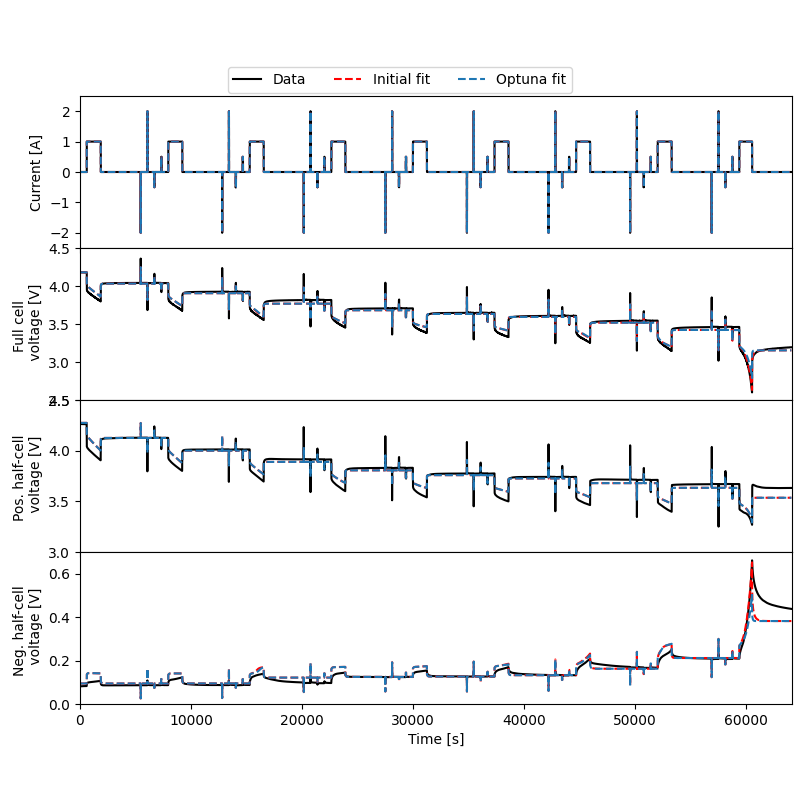

In [13]:
%matplotlib widget
V_offset = 3.34+0.084
fig,axs = plt.subplots(4,1, figsize = (8,8), sharex = True)
axs = axs.flatten()
plt.subplots_adjust(hspace=0, wspace=0, left=0.1, right=0.99, bottom=0.12)

# Simulate with initial parameters
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe")  #,dt_max=50
current_interpolant = pybamm.Interpolant(cycler_data_ds.t.values, cycler_data_ds.I.values, pybamm.t)
parameter_values = update_pulse_parameter_values(pulses.iloc[0],parameter_values.copy())
parameter_values.update(
{
    "Current function [A]": current_interpolant,
    "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
    "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
    "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
    "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
    
})
sim = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver)
sol = sim.solve(
    t_eval=cycler_data_ds.t.values,
    inputs = {
    "posDiffusion": param0, 
    "negDiffusion": param1, 
    "posKinetics": param2,
    "negKinetics": param3,
    })

# Simulate with fitted parameters
# k_i0p_opt = study.best_trials[0].params["k_i0p"]
# k_i0n_opt = study.best_trials[0].params["k_i0n"]
parameter_values_opt = study.best_trials[0].user_attrs["parameter_values"]
sim_opt = pybamm.Simulation(spme, parameter_values=parameter_values_opt, solver=fast_solver)
sol_opt = study.best_trials[0].user_attrs["sol"]
t = sol["Time [s]"].entries
I = sol["Current [A]"].entries
Vt = sol["Terminal voltage [V]"].entries

t_opt = sol_opt["Time [s]"].entries
I_opt = sol_opt["Current [A]"].entries
Vt_opt = sol_opt["Terminal voltage [V]"].entries

t_data = cycler_data.t.values
I_data = cycler_data.I.values
V_data = cycler_data.V.values
t_vdf_data = vdf_data.t.values
V_pos_data = vdf_data.V_pos.values
V_neg_data = vdf_data.V_neg.values

# plot current
ax = axs[0]
ax.plot(t_data,I_data,'k', label = 'Data')
ax.plot(t,I,'r--', label = 'Initial fit')
ax.plot(t_opt,I_opt,'--', label = f'Optuna fit')
ax.set_xlim([t_data[0],t_data[-1]])
ax.set_ylim([-2.5,2.5])
ax.set_ylabel('Current [A]')
# ax.set_xticklabels([])
        
# plot full cell voltage
ax = axs[1]
ax.plot(t_data, V_data,'k', label = 'Data')
ax.plot(t,Vt,'r--', label = 'Initial fit')
ax.plot(t_opt,Vt_opt,'--', label = f'Optuna fit')
ax.set_ylabel('Full cell \n voltage [V]')
# ax.set_xticklabels([])
ax.set_ylim([2.5,4.5])
ax.set_xlim([t_data[0],t_data[-1]])

# plot pos voltage
ax = axs[2]
Vpos_elec =sol['Positive electrode 3E potential [V]'].entries
# Vpos_surf_pot=sol['Positive electrode surface potential difference at separator interface [V]'].entries
Vpos_elec_opt =sol_opt['Positive electrode 3E potential [V]'].entries
ax.plot(t,Vpos_elec,'r--', label = "Electrode 3E potential")
ax.plot(t_data_vdf,V_offset + V_pos_data,'k',label = 'Data')
ax.plot(t,Vpos_elec_opt,'--', label = "Electrode 3E potential")
ax.set_ylabel('Pos. half-cell \n voltage [V]')
# ax.set_xticklabels([])
ax.set_ylim([3,4.5])
ax.set_xlim([t_data[0],t_data[-1]])

# plot neg voltage
ax = axs[3]
Vneg_elec =sol['Negative electrode 3E potential [V]'].entries
Vneg_elec_opt =sol_opt['Negative electrode 3E potential [V]'].entries
ax.plot(t_data_vdf,V_offset-V_neg_data,'k',label = 'Data')
ax.plot(t,Vneg_elec,'r--',label = "Electrode 3E potential")
ax.plot(t,Vneg_elec_opt,'--',label = "Electrode 3E potential")
ax.set_ylabel('Neg. half-cell \n voltage [V]')
ax.set_xlim([t_data[0],t_data[-1]])    
ax.set_ylim([0,0.7])
# ax3.legend(loc="upper left")


ax.set_xlabel('Time [s]')
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center', ncol = 5, bbox_to_anchor=(0.5, .9), fancybox=True) #prop={'size': 10},  
# fig.suptitle(cell_name + f' (RPT {rpt_num})')
plt.savefig('./figs/3E_fitting_wrapped.jpg',format='jpg',dpi=300)
plt.show()



### Calculate RMSEs

In [20]:
rmses_sol = []
for s in [sol, sol_opt]:   
    t = s["Time [s]"].entries
    V_sim_full = s["Terminal voltage [V]"].entries
    V_sim_neg =s['Negative electrode 3E potential [V]'].entries
    V_sim_pos =s['Positive electrode 3E potential [V]'].entries
    V_data_full = cycler_data_ds.V.values
    V_data_neg = V_offset - vdf_data.V_neg
    V_data_pos = V_offset + vdf_data.V_pos
    t_data = cycler_data_ds.t.values
    t_data_vdf = vdf_data.t.values

    # calculate rmses 
    rmses = []
    for (v_sim, v_data, t_test_data) in zip([V_sim_full, V_sim_pos,V_sim_neg],[V_data_full, V_data_pos, V_data_neg], [t_data, t_data_vdf,t_data_vdf]): 
        v_data_interp = np.interp(t,t_test_data,v_data) 
        voltage_difference = (v_sim - v_data_interp)*1000 # mV
        rmse_V = np.sqrt(np.mean(voltage_difference**2))
        rmses.append(round(rmse_V,1))
    rmses.append(round(np.mean(rmses),1))
    rmses_sol.append(rmses)
    print(rmses)

# calculate percent change in rmse
[(j-i)/i*100 for (i,j) in zip(rmses_sol[0],rmses_sol[1])] 


[52.4, 94.5, 32.7, 59.9]
[56.6, 94.6, 37.8, 63.0]


[8.015267175572523, 0.1058201058200998, 15.59633027522934, 5.175292153589318]

### Plot concentration dependence

In [23]:
# # correct answer
# cs = CubicSpline(y, fit_params.k_D_p, bc_type='natural')
# print(cs([0.2,0.5,0.7, 0.95]))

# rebuild and test explicit cubic spline function 
def cs_eval(cs, xs):
    x0s,c = cs.x, cs.c
    y = []
    for x in xs: 
        S = []
        for i,x0 in enumerate(x0s[0:-1]): #(x-x0)/(x0s[i+1]-x0)*
            s = ((x0<x) and x<=x0s[i+1])*(c[0,i]*(x - x0)**3 + c[1,i]*(x - x0)**2 + c[2,i]*(x - x0)**1 + c[3,i])
            S.append(s)
            
        # allow extrapolation
        S.append((x<x0s[0])*(c[0,0]*(x - x0s[0])**3 + c[1,0]*(x - x0s[0])**2 + c[2,0]*(x - x0s[0])**1 + c[3,0]))
        S.append((x>x0s[-1])*(c[0,i]*(x - x0s[-2])**3 + c[1,i]*(x - x0s[-2])**2 + c[2,i]*(x - x0s[-2])**1 + c[3,i])) # last point added by cubic spline to satisfy natural bc
        y.append(sum(S))
    return y
# print([round(i,8) for i in cs_eval(cs, [0.2,0.5,0.7, 0.95])])

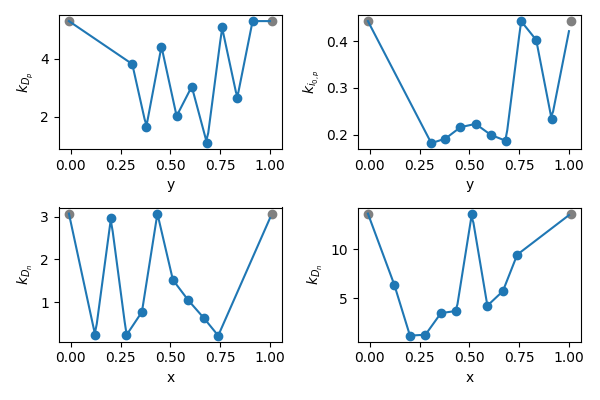

In [24]:
%matplotlib widget
# create dataframe with fitted parameters and soc at each pulse
fit_params = study.best_trials[0].user_attrs["fit_params"]

# plot trends vs soc
fig,axs = plt.subplots(2,2, figsize = (6,4))
# plt.subplots_adjust(hspace=0, wspace=0.15, left=0.1, right=0.99, bottom=0.12)

# add values to avoid extrapolation
y_fit = np.arange(-0.01,1.01,0.01)
y = fit_params.y #y_0 - fit_params.soc * (y_0 - y_100)
y = np.insert(y,0,-0.01)
y = np.append(y,1.01)
x_fit =np.arange(-0.01,1.01,0.01)
x = fit_params.x[len(fit_params.x)::-1] #x_0 + fit_params.soc * (x_100 - x_0)
x = np.insert(x,0,-0.01)
x = np.append(x,1.01)

ax=axs[0,0]
k_Dp = fit_params.k_D_p.values
k_Dp = np.insert(k_Dp,0,max(k_Dp))
k_Dp = np.append(k_Dp,max(k_Dp))
k_Dp_fit = np.interp(y_fit,y,k_Dp) #cs_eval(CubicSpline(y,k_Dp), y_fit) #, bc_type='natural'
k_Dp_fit = [max(k, 0.1) for k in k_Dp_fit]
ax.scatter(fit_params.y, fit_params.k_D_p)
ax.scatter([-0.01, 1.01], [max(k_Dp)]*2, c = 'grey')
ax.plot(y_fit,k_Dp_fit)
ax.set_ylabel("$k_{D_p}$")
ax.set_xlabel("y")

ax=axs[0,1]
k_i0p = fit_params.k_i0p.values
k_i0p = np.insert(k_i0p,0,max(k_i0p))
k_i0p = np.append(k_i0p,max(k_i0p))
k_i0p_fit = np.interp(y_fit, y, k_i0p) #cs_eval(CubicSpline(y,k_i0p), y_fit) #, bc_type='natural'
k_i0p_fit = [max(k, 0.1) for k in k_i0p_fit]
ax.scatter(fit_params.y, fit_params.k_i0p)
ax.scatter([-0.01, 1.01], [max(k_i0p)]*2, c = 'grey')
ax.plot(y_fit,k_i0p_fit)
ax.set_ylabel("$k_{i_{0,p}}$")
ax.set_xlabel("y")

ax=axs[1,0]
k_Dn = fit_params.k_D_n[len(x)::-1].values
k_Dn = np.insert(k_Dn,0,max(k_Dn))
k_Dn = np.append(k_Dn,max(k_Dn))
k_Dn_fit = np.interp(x_fit,x,k_Dn) #cs_eval(CubicSpline(x,k_Dn), x_fit)
k_Dn_fit = [max(k, 0.1) for k in k_Dn_fit]
ax.scatter(fit_params.x, fit_params.k_D_n)
ax.scatter([-0.01, 1.01], [max(k_Dn)]*2, c = 'grey')
ax.plot(x_fit,k_Dn_fit)
ax.set_ylabel("$k_{D_n}$")
ax.set_xlabel("x")

ax=axs[1,1]
k_i0n = fit_params.k_i0n[len(x)::-1].values
k_i0n = np.insert(k_i0n,0,max(k_i0n))
k_i0n = np.append(k_i0n,max(k_i0n))
k_i0n_fit = np.interp(x_fit,x,k_i0n) #cs_eval(CubicSpline(x,k_i0n), x_fit)
k_i0n_fit = [max(k, 0.1) for k in k_i0n_fit]
ax.scatter(fit_params.x, fit_params.k_i0n)
ax.scatter([-0.01, 1.01], [max(k_i0n)]*2, c = 'grey')
ax.plot(x_fit,k_i0n_fit)
ax.set_ylabel("$k_{D_n}$")
ax.set_xlabel("x")

plt.tight_layout()
plt.savefig('./figs/param_vs_sto_wrapped.jpg',format='jpg',dpi=300)

## Archive

In [ ]:
# correct answer
cs = CubicSpline(y, fit_params.k_D_p, bc_type='natural')
print(cs([0.2,0.5,0.7, 0.95]))

# test explicit function 
def cs2(xs, x0s,c):
    y = []
    for x in xs: 
        S = []
        for i,x0 in enumerate(x0s[0:-1]): #(x-x0)/(x0s[i+1]-x0)*
            s = ((x0<x) and x<x0s[i+1])*(c[0,i]*(x - x0)**3 + c[1,i]*(x - x0)**2 + c[2,i]*(x - x0)**1 + c[3,i])
            S.append(s)
        # allow extrapolation
        S.append((x<x0s[0])*(c[0,0]*(x - x0s[0])**3 + c[1,0]*(x - x0s[0])**2 + c[2,0]*(x - x0s[0])**1 + c[3,0]))
        S.append((x>x0s[-1])*(c[0,i]*(x - x0s[-2])**3 + c[1,i]*(x - x0s[-2])**2 + c[2,i]*(x - x0s[-2])**1 + c[3,i])) # last point added by cubic spline to satisfy natural bc
        y.append(sum(S))
    return y
print([round(i,8) for i in cs2([0.2,0.5,0.7, 0.95], cs.x,cs.c)])

In [ ]:
fig, ax = pybamm.plot_voltage_components(sol,split_by_electrode=True)
ax.set_ylim([2.5,4.5])

In [ ]:
pulses = [] # list of dfs

# build dicts
for ((start, end),(start_vdf, end_vdf)) in zip(zip(pulse_idx[0:-1],pulse_idx[1::]), zip(pulse_idx_vdf[0:-1],pulse_idx_vdf[1::])):
        pulse = {"t": t_data[start:end] - t_data[start],
                "t0": t_data[start],
                "I": I_data[start:end],
                "V": V_data[start:end],
                "SOC":soc_data[start:end],
                "t_vdf": t_data_vdf[start_vdf:end_vdf] - t_data_vdf[start_vdf], 
                "t_vdf0":t_data_vdf[start_vdf],
                "V_neg_data": V_neg_data[start_vdf:end_vdf],
                "V_pos_data":V_pos_data[start_vdf:end_vdf],
                }
        pulses.append(pulse)

# list of dicts to df
pulses = pd.DataFrame(pulses)

fig,axs = plt.subplots(1,9, figsize = (10,4),sharex=True)
# fig,ax = plt.subplots(4,1,figsize=(8,8), sharex=True)
plt.subplots_adjust(hspace=0.01, wspace=0.01, left=0.1, right=0.99, bottom=0.12)
# axs = axs.flatten()
V_offset = 3.34+0.084
for i,pulse in pulses.iterrows():
        
        # V_data_full = V_data
        # V_data_neg = V_offset - V_neg_data
        # V_data_pos = V_offset + V_pos_data
        ax = axs[i]
        ax.plot(pulse.t_vdf, V_offset + pulse.V_pos_data, color = 'red')
        ax.set_title(f'Pulse {i+1}')
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Pos. electrode \n voltage [V]")
        # ax.set_xticklabels([])
        # ax.set_ylim([2.5,4.5])
        
        ax = axs[i]
        ax.plot(pulse.t, pulse.V, 'k')
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Full cell \n voltage [V]")
        # ax.set_xticklabels([])
        # ax.set_ylim([2.5,4.5])

        ax = axs[i]
        ax.plot(pulse.t_vdf, V_offset - pulse.V_neg_data, color = 'grey')
        if i!=0:
                ax.set_yticklabels([])
        else:
                ax.set_ylabel("Neg. electrode \n voltage [V]")
        ax.set_ylim([0,4.5])

axs[4].set_xlabel("Time [s]")

### multiobjective opt code

In [ ]:
def objective(trial):
    # define parameters and suggested ub and lb 
    k_min = 0.1
    k_max = 2
    k_D_p = trial.suggest_float("k_D_p", k_min, k_max)
    k_D_n = trial.suggest_float("k_D_n", k_min, k_max)
    k_i0p = trial.suggest_float("k_i0p", k_min, k_max)
    k_i0n = trial.suggest_float("k_i0n", k_min, k_max)
    # k_sigma_e = trial.suggest_float("k_sigma_e", k_min, k_max)
    # k_D_e = trial.suggest_float("k_D_e", k_min, k_max)

    # solve model 
    try: # in case simulation fails
        sol = sim.solve( # define sim before calling this function in next cell 
            t_eval=pulse.t,
            inputs = {
            "posDiffusion": param0*k_D_p, 
            "negDiffusion": param1*k_D_n, 
            "posKinetics": param2*k_i0p,
            "negKinetics": param3*k_i0n,
            "electCond" : 1,#*k_sigma_e,
            "electDiff" : 1#*k_D_e,
            })
        
        # define voltages from sim
        t = sol["Time [s]"].entries
        V_sim_full = sol["Terminal voltage [V]"].entries
        V_sim_neg =sol['Negative electrode 3E potential [V]'].entries
        V_sim_pos =sol['Positive electrode 3E potential [V]'].entries
        V_data_full = pulse.V
        V_data_neg = V_offset - pulse.V_neg_data
        V_data_pos = V_offset + pulse.V_pos_data
        t_data = pulse.t
        t_data_vdf = pulse.t_vdf
        
        # calculate rmses 
        rmses = []
        for (v_sim, v_data, t_test_data) in zip([V_sim_full, V_sim_neg, V_sim_pos],[V_data_full, V_data_neg, V_data_pos], [t_data, t_data_vdf,t_data_vdf]): 
        # for (v_sim, v_data, t_test_data) in zip([V_sim_full],[pulse.V], [pulse.t]):
            v_data_interp = np.interp(t,t_test_data,v_data) 
            voltage_difference = (v_sim - v_data_interp)*1000 # mV
            rmse_V = np.sqrt(np.mean(voltage_difference**2))
            rmses.append(rmse_V)
            # dVdt_sim = np.diff(v_sim)/np.diff(t)
            # dVdt_data = np.diff(v_data_interp)/np.diff(t)
            # delta_dVdt = (dVdt_sim-dVdt_data) * 1000
            # rmse_dV = np.sqrt(np.mean(delta_dVdt**2))
    except:
        rmses = rmse_V = [1e6]*3

    rmse_full = rmses[0]
    rmse_neg = rmses[1]
    rmse_pos = rmses[2]
    # rmse_combined = sum(rmses)

    
    # pruning not supported for multiobjective
    # if trial.should_prune():
    #     raise optuna.exceptions.TrialPruned()
    return rmse_full, rmse_neg, rmse_pos



In [ ]:
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe")  #,dt_max=50
# At each SOC/long discharge pulse...
for p,pulse in pulses[0:1].iterrows():
    # update parameters and simulation
    parameter_values = update_pulse_parameter_values(pulse,parameter_values) 
    sim = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver)

    # setup optuna study
    study = optuna.create_study(study_name = 'Pulse ' + str(p+1),directions = ["minimize"]*3) # minimize by default directions = ["minimize"]*3,
    study.optimize(objective, n_trials = 20, timeout = 60)

    # run study to find param set
    pulse['fit'] = study.best_trials

In [ ]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_data, I_data, V_data = downsample_data(t_data0,I_data0,V_data0,5e-3,.5,230)
fig,ax = plt.subplots(2,1, sharex=True)
ax1 = ax.flat[0]
ax1.plot(t_data0,V_data0)
ax1.plot(t_data,V_data,'x')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data0,I_data0)
ax2.plot(t_data,I_data,'x')
ax2.set_ylabel('Current [A]')
plt.show()

In [ ]:
#parameter_values = pybamm.ParameterValues("Siegel2022")
import Siegel2022
param_dict = Siegel2022.get_parameter_values()
#param_dict = {"a": 1, "b": 2, "c": 3}
parameter_values = pybamm.ParameterValues(param_dict)   
print(f"parameter values are {parameter_values}")

parameter_values.update(
    {
        "Negative electrode active material volume fraction": 0.66735,
        "Positive electrode active material volume fraction": 0.70513,
    #    "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
    #    "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        "Lower voltage cut-off [V]": 2.7, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

q_init, x_init, y_init=JS_Get_xy_from_voltage(parameter_values,4)
print(q_init)
print(x_init)
print(y_init)

In [ ]:
def JS_Get_xy_from_voltage(parameter_values,initial_voltage):
    # First we solve for x_100 and y_100
    param = pybamm.LithiumIonParameters()
    Vmin = 2.8
    Vmax = 4.2
    Q_n = parameter_values.evaluate(param.n.Q_init)
    Q_p = parameter_values.evaluate(param.p.Q_init)
    Q_Li = parameter_values.evaluate(param.Q_Li_particles_init)
    print(Q_n)
    print(Q_p)
    print(Q_Li)

    U_n = param.n.prim.U
    U_p = param.p.prim.U
    T_ref = param.T_ref

    model = pybamm.BaseModel()

    x_100 = pybamm.Variable("x_100")
    y_100 = (Q_Li - x_100 * Q_n) / Q_p

    y_100_min = 1e-10

    x_100_upper_limit = (Q_Li - y_100_min*Q_p)/Q_n
    print(x_100_upper_limit)
    model.algebraic = {x_100: U_p(y_100, T_ref) - U_n(x_100, T_ref) - Vmax}

    model.initial_conditions = {x_100: x_100_upper_limit}

    model.variables = {
        "x_100": x_100,
        "y_100": y_100
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])

    x_100 = sol["x_100"].data[0]
    y_100 = sol["y_100"].data[0]

    for var in ["x_100", "y_100"]:
        print(var, ":", sol[var].data[0])

    # Based on the calculated values for x_100 and y_100 we solve for x_0
    model = pybamm.BaseModel()

    x_0 = pybamm.Variable("x_0")
    Q = Q_n * (x_100 - x_0)
    y_0 = y_100 + Q/Q_p

    model.algebraic = {x_0: U_p(y_0, T_ref) - U_n(x_0, T_ref) - Vmin}
    model.initial_conditions = {x_0: 0.1}

    model.variables = {
        "Q": Q,
        "x_0": x_0,
        "y_0": y_0,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])
    Q=sol["Q"].data[0]

    for var in ["Q", "x_0", "y_0"]:
        print(var, ":", sol[var].data[0])


    # Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
    Q_init = pybamm.Variable("Q_init")

    model.algebraic = {Q_init: U_p(y_100-(Q_init-Q)/Q_p, T_ref) - U_n(x_100+(Q_init-Q)/Q_n, T_ref) - initial_voltage}
    model.initial_conditions = {Q_init: Q}

    model.variables = {
        "Q_init": Q_init,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])


    for var in ["Q_init"]:
        print(var, ":", sol[var].data[0])
    Q_init=sol["Q_init"].data[0]
    return Q_init, x_100+(Q_init-Q)/Q_n, y_100-(Q_init-Q)/Q_p

In [ ]:
raw_cycler_data=c.data.raw

start_time_exp=vdf_data["Timestamp"][0]/1000 # epoch time time in ms and convert to s
start_time_arbin=raw_cycler_data["date_time"].iloc[0].value/1e9+3600*4-1855 # UTC offset for EST, need to also be cognizent of DST?


fig, ax = plt.subplots(1, 1)
ax.plot(raw_cycler_data["test_time"],raw_cycler_data["voltage"],vdf_data["Test Time"]+start_time_exp-start_time_arbin,vdf_data["Potential"])
plt.show()

fig, ax = plt.subplots(1, 1)
ax.plot(vdf_data["Test Time"]+start_time_exp-start_time_arbin,3.345+0.0007-vdf_data["Vneg"])
plt.show()

timtot=raw_cycler_data["test_time"]
find_dupe_times=timtot.duplicated(keep='first')
timtot[find_dupe_times]=timtot[find_dupe_times]+2e-3
find_dupe_times2=timtot.duplicated(keep='first')
t_start = 32000
t_end = 62000
#t_start=163648 #C/4 discharge

t_dataF=timtot.to_numpy().flatten()-t_start
V_dataF=(raw_cycler_data["voltage"]).flatten()
I_dataF=(raw_cycler_data["current"]).flatten()
print(type(t_dataF))

print(type(I_dataF))
fig, ax = plt.subplots(1, 1)
ax.plot(t_dataF,V_dataF)
plt.show()




In [ ]:
def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    fig,ax = plt.subplots(2,1)
    ax1 = ax.flat[0]
    ax1.plot(t,v)
    ax2 = ax.flat[1]
    ax2.plot(t,deriv_V)
    ax2.set_ylim([-.01, .01])
    #ax2.plot(t_data,I_data,'x')
    plt.show()

    dv_changes=abs(deriv_V)>dv
    #dv_changes=(np.abs(np.diff(v, prepend=0)/np.diff(t, prepend=0))>dv) + (np.abs(np.diff(v, append=0)/np.diff(t, append=0))>dv)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(di_changes[ii]):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dv/abs(deriv_V[ii]) ):
            Tlast=t[ii]
            dt_changes[ii]=True
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_data,I_data,V_data=downsample_data(t_dataF[t_dataF>=0],I_dataF[t_dataF>=0],V_dataF[t_dataF>=0],5e-3,.5,230)
fig,ax = plt.subplots(2,1)
# plt.title(str(cells[i]) + "Input Data")

#%matplotlib ipympl
ax1 = ax.flat[0]
ax1.plot(t_dataF,V_dataF)
ax1.plot(t_data,V_data,'x')
ax2 = ax.flat[1]
ax2.plot(t_dataF,I_dataF)
ax2.plot(t_data,I_data,'x')

plt.show()

In [ ]:

#%matplotlib widget
fig,ax = plt.subplots(3,1)
# plt.title(str(cells[i]) + "Input Data")
ax1 = ax.flat[0]
ax1.plot(t_data,V_data,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_data,I_data,'k')
ax2.plot(t,-I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
#Vneg_elec =sol['X-averaged separator electrolyte potential [V]'].entries
Vneg_elec=sol['Negative electrode 3E potential [V]'].entries
#Vneg_surf_pot=sol['Negative electrode reaction overpotential [V]'].entries[10,:]
#Vneg_surf_pot=sol['X-averaged negative electrode surface potential difference [V]'].entries
Vneg_surf_pot=sol['Negative electrode surface potential difference at separator interface [V]'].entries
ax3 = ax.flat[2]
ax3.plot(vdf_data["Test Time"]+start_time_exp-start_time_arbin-t_start,-3.34-0.084+vdf_data["Vneg"],'k')
ax3.plot(t,Vneg_elec,'r--')
#ax3.plot(t,-Vneg_surf_pot,'b--')
ax3.set_xlim(left=0)
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Half_cell-Voltage')
ax3.set_xlim([0,t_end])
ax2.set_xlim([0,t_end])
ax1.set_xlim([0,t_end])
ax1.set_ylim([2.7, 4.2])
#ax3.set_ylim([-.05, -0.7])
# ax1.set_ylim([3.5, 4.2])
# ax3.set_ylim([-.05, -0.25])

#ax1.set_ylim([4.05, 4.1])
fig.tight_layout()
plt.show()

voltage_difference = (Vt - V_data[range(len(Vt))])*1000
rmse = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
print("Checking Voltage lengths for RMSE: ", len(Vt), len(V_data), "RMSE (mV) :", rmse)

In [ ]:
sol.plot(
    [
        [
            "Negative electrode surface potential difference at separator interface [V]",
            "Negative electrode 3E potential [V]",
        ],
        [
            "Positive electrode surface potential difference at separator interface [V]",
            "Positive electrode 3E potential [V]",
        ],
        "Voltage [V]",
    ]
)

In [ ]:
def filtering(hppc_data_raw):

    if 'Weight' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Weight'], axis=1)
    if 'Diff' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Diff'], axis=1)
    if 'Binary' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Binary'], axis=1)

    capacity = 3.5

    # Clipping dataframe to just first block of RPTs
    df = hppc_data_raw.copy()
    df['Time'] = df.Timestamp - df.Timestamp.min()
    df['index_col'] = df.index # Track index position of each dataframe so we're reorganizing the reduced dataframe appropriately

    # Intializing Weight and Binary columns
    df.insert(loc=0, column='Binary', value=0)
    df.insert(loc=0, column='Weight', value=0)

    # Current sign change tracking
    df.loc[df['Current (A)'] > 0, 'Binary'] = 1
    df.loc[df['Current (A)'] < 0, 'Binary'] = 1
    current_sign_change = df[df.Binary.diff() !=0].index.tolist()

    # 50 seconds after current sign change
    for x in range(0, 50):

        csign_change = [i + x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # 10 seconds before current sign change
    for x in range(0, 10):

        csign_change = [i - x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # Any non-zero current should not be reduced
    df.loc[df['Current (A)'] != 0, 'Weight'] = 1

    # SOC setting should be sampled at a lower rate
    df.loc[df.DataTag == 0.5, 'Weight'] = 2
    df.loc[df.DataTag == -0.5, 'Weight'] = 2

    df['DateTime'] = pd.to_datetime(df.Time, unit='s')

    # Resampling dataframe sections accordingly
    weight_1_df = df[df.Weight == 1]
    needs_resampling = df[df.Weight == 0]
    soc_setting = df[df.Weight == 2]
    resampled = needs_resampling.resample('10S', on='DateTime').mean()
    resampled_soc_setting = soc_setting.resample('10s', on='DateTime').mean()
    resampled_df = pd.concat([weight_1_df, resampled, resampled_soc_setting])
    resampled_df = resampled_df.sort_values(by=['index_col'])

    pct_reduced = (df.shape[0] - resampled_df.shape[0]) / df.shape[0] * 100
    print('% reduced', pct_reduced)
    return resampled_df

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (current_model < threshold_low) | (current_model > threshold_high)
sign_index_model = np.where(condition_model)[0]
Vpulse_model = v_model[sign_index_model]
Vpulse_test = v_test[sign_index_model]
t = t_model[sign_index_model]

error = [(Vpulse_model[i] - Vpulse_test[i])**2.0 for i in range(len(Vpulse_model))]
error = [np.sqrt(i) * 1000 for i in error]
RMSE = np.sqrt(np.mean(error))

plt.plot(t,error,'.')
plt.xlabel('test time (s)')
plt.ylabel('error: mV')
plt.title("Cell 16 Pulse Accuracy (mV)") 

error_whole = [((v_model[i] - v_test[i])**2.0)**0.5*1000 for i in range(len(v_test))]
RMSE = np.mean(error_whole[:49999])
# plt.plot(t_model[:49999],error_whole[:49999])
# plt.xlabel('test time (s)')
# plt.ylabel('error: mV')
# RMSE
if not cell_output_dict: 
    cell_output_dict= {}
cell_output_dict["cell16"] = [v_test,v_model,t_model, Vpulse_model, Vpulse_test,t,error ] 
RMSE

In [ ]:
hppc_data

In [ ]:
for cell in cell_output_dict: 
    y = (cell_output_dict[cell][0] - cell_output_dict[cell][1])*1000
    x = cell_output_dict[cell][2]

    y = y[:500000]
    x = x[:500000]
    plt.plot(x,y,'.',label=cell)
plt.xlabel('time')
plt.ylabel('Error mV')
plt.title('Error for each fitting')
plt.legend()
plt.show()

In [ ]:
Vt_after1 = np.interp(t_data, t, Vt)
t_after1 = np.interp(t_data, t, t)
voltage_difference = Vt_after1 - V_data
len(t_after1), len(Vt_after1), len( 
#rmse[i] = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))

In [ ]:
#Let's see if this black Screen's again. 
len(Vt), len(V_data)
#Calculate RMSE: 
error = [(Vt[i] - V_data[i])**2.0 for i in range(len(Vt))]
RMSE = np.sqrt(np.mean(error))
print(round(RMSE*1000,1), "mV error at C/3")

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t,Vt, label='physical')
plt.plot(t_data, V_data, label='simulation')
plt.xlabel('time')
plt.ylabel("Voltage")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

#min(df["Potential (V)"])
import matplotlib.pyplot as plt
plt.plot(t,-I, '.',label='physical',)
plt.plot(t_data, I_data ,'.',label='simulation')
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

plt.plot(data_time,data_current, '.',label='physical',)
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

In [ ]:
len(V_data), len(Vt)
len(t), len(t_data)

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (I < threshold_low) | (I > threshold_high)
sign_index_model = np.where(condition_model)[0]
condition_test = (I_data < threshold_low) | (I_data > threshold_high)
sign_index_test = np.where(condition_test)[0]
Vpulse_model = V_data[sign_index_model]
Vpulse_test = V_data[sign_index_test]
len(Vpulse_test), len(Vpulse_model) 

In [ ]:
cell_num.append(cells[0])
cell_errors.append(RMSE)
cell_voltage.append(Vt)
cell_prediction.append(V_data)
cell_v0.append(Vt[0])

In [ ]:
cell_output_dict = {}